In [65]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import os, glob
import ROOT
from scipy import stats

try:
#     plt.style.use('belle2')
    plt.style.use('belle2_serif')
#     plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style")   
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density, MC_stack_plot_weight

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
def plot_stack_with_data(dataframes, tag_order, labels, data_df, var, bins, xlabel, output):
    data_list = [dataframes[tag][var] for tag in tag_order]
    scale_list = [dataframes[tag]["ds_weight"] for tag in tag_order]
    colors = b2helix(len(data_list))

    xbins = np.linspace(*bins, 101)
    bin_centers = (xbins[1:] + xbins[:-1]) / 2
    bin_width = xbins[1] - xbins[0]

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Stack plot (✔ label 순서 그대로)
    ax.hist(data_list, bins=xbins, weights=scale_list, stacked=True, label=labels,
            histtype='stepfilled', color=colors, edgecolor='black')
    
    # MC stat. error
    flat_data = np.concatenate([np.asarray(d) for d in data_list])
    flat_weights = np.concatenate([np.asarray(w) for w in scale_list])
    sum_w = stats.binned_statistic(flat_data, flat_weights, bins=xbins, statistic="sum")[0]
    sum_w2 = stats.binned_statistic(flat_data, flat_weights**2, bins=xbins, statistic="sum")[0]
    ax.bar(bin_centers, 2*np.sqrt(sum_w2), width=bin_width, bottom=sum_w - np.sqrt(sum_w2),
           color='black', hatch='////', fill=False, lw=0, label="MC stat. unc.")

    if data_df!=None:
        # Data points
        data_hist, _ = np.histogram(data_df[var], bins=xbins)
        ax.errorbar(bin_centers, data_hist, yerr=np.sqrt(data_hist), fmt='ko', markersize=4, label="Data")
        
    ax.set_xlim(*bins)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"Entries / ({bin_width:.4f} GeV/$c^2$)")
    # ax.set_ylim(0,3000)
    ax.legend(loc="upper right", ncol=2, prop={'size':13})
    plt.tight_layout()
    plt.savefig(output)
    plt.show()


In [67]:
def do_BCS(var='BDT', df=None, ascending=False):
    if df is None:
        df = pd.DataFrame()
    df_copied = df.copy()
    df_copied['rank_study'] = df_copied.groupby(
        ['__experiment__', '__run__', '__event__', '__production__']
    )[var].rank(ascending=ascending, method='first')
    
    final_df = df_copied.query("rank_study == 1").drop(columns='rank_study')
    return final_df

In [68]:
def do_random_choice(var=None, df=None, random_state=251124):
    if df is None:
        df = pd.DataFrame()
    
    np.random.seed(random_state)
    
    # Group by the same columns as do_BCS and sample one row per group
    final_df = df.groupby(
        ['__experiment__', '__run__', '__event__', '__production__'], group_keys=False
    ).apply(lambda x: x.sample(n=1))
    
    return final_df

In [69]:
def do_random_choice_fast(df=None, random_state=251124):
    if df is None or df.empty:
        return pd.DataFrame()
    
    np.random.seed(random_state)
    
    # Add a random number column
    df_copied = df.copy()
    df_copied['_rand'] = np.random.rand(len(df_copied))
    
    # For each group, get the index of the row with max random number
    idx = df_copied.groupby(
        ['__experiment__', '__run__', '__event__', '__production__']
    )['_rand'].idxmax()
    
    final_df = df_copied.loc[idx].drop(columns='_rand')
    
    return final_df

In [70]:
def load_root_files(BCS_var, dir_topo_list, dir_list, tags, tree, cut, variables):
    file_map = {tag: [] for tag in tags}
    for tag in tags:
        if tag != "ccbar":
            for d in dir_list:
                path = os.path.join(d, f"weighted_{tag}.no_BCS.root")
                if os.path.exists(path):
                    file_map[tag].append(path)
        else:
            for d in dir_topo_list:
                path = os.path.join(d, f"standard.root")
                if os.path.exists(path):
                    file_map[tag].append(path)            


    dataframes = {}
    for tag in tags:
        # ccbar 분리
        if tag == "ccbar":
            if BCS_var == 'BDT':
                dfs = [do_BCS(var='BDT', df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['nAllSigCascDcyBr_14','nAllSigCascDcyBr_4','nAllSigCascDcyBr_8','BDT','nAllSigCascDcyBr_16', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__']),ascending=False) for fp in file_map[tag]]
            elif BCS_var == 'Dp_chiProb':
                dfs = [do_BCS(var='Dp_chiProb', df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['nAllSigCascDcyBr_14','Dp_chiProb','nAllSigCascDcyBr_4','nAllSigCascDcyBr_8','BDT','nAllSigCascDcyBr_16', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__']),ascending=False) for fp in file_map[tag]]
            elif BCS_var == 'random':
                dfs = [do_random_choice_fast(df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['nAllSigCascDcyBr_14','Dp_chiProb','nAllSigCascDcyBr_4','nAllSigCascDcyBr_8','BDT','nAllSigCascDcyBr_16', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__'])) for fp in file_map[tag]]
            elif BCS_var == 'no_BCS':
                dfs = [get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['nAllSigCascDcyBr_14','Dp_chiProb','nAllSigCascDcyBr_4','nAllSigCascDcyBr_8','BDT','nAllSigCascDcyBr_16', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__']) for fp in file_map[tag]]                
            else:
                ValueError('Do correct BCS')
            
            df = pd.concat(dfs, ignore_index=True)
            df["ds_weight"] *= 1/4  # Scale weights
            
            df_signal = df.query("Dp_isSignal == 1").copy()
            df_signal["ds_weight"] = df_signal["ds_weight"]  # 그대로 유지
            df_signal.drop(columns="Dp_isSignal", inplace=True)

            # df_bkg_comb = df.query("(nAllSigCascDcyBr_4 <= 0) and (nAllSigCascDcyBr_8 <= 0) and (nAllSigCascDcyBr_16 <= 0)").copy()
            df_bkg_comb = df.query("(nAllSigCascDcyBr_4 <= 0) and (nAllSigCascDcyBr_8 <= 0)").copy()
            # df_bkg_comb = df.query("(nAllSigCascDcyBr_16 > 0) and (nAllSigCascDcyBr_4 <= 0) and (nAllSigCascDcyBr_8 <= 0)").copy()

            df_bkg_comb["ds_weight"] = df_bkg_comb["ds_weight"]
            df_bkg_comb.drop(columns="Dp_isSignal", inplace=True)           

            dataframes["ccbar_bkg_comb"] = df_bkg_comb.query(cut)
        else:
            if BCS_var == 'BDT':
                dfs = [do_BCS(var='BDT', df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['Dp_chiProb', 'BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__']),ascending=False) for fp in file_map[tag]]
            elif BCS_var == 'Dp_chiProb':
                dfs = [do_BCS(var='Dp_chiProb', df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['Dp_chiProb', 'BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__']),ascending=False) for fp in file_map[tag]]
            elif BCS_var == 'random':
                dfs = [do_random_choice_fast(df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['Dp_chiProb', 'BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__'])) for fp in file_map[tag]]
            elif BCS_var == 'no_BCS':
                dfs = [get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['Dp_chiProb', 'BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__']) for fp in file_map[tag]]                
            else:
                ValueError('Do correct BCS')
            # dfs = [do_BCS(var='BDT', df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables +  ['Dp_chiProb', 'BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__']),ascending=False) for fp in file_map[tag]]
            # dfs = [do_BCS(var='Dp_chiProb', df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['Dp_chiProb', 'BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__']),ascending=False) for fp in file_map[tag]]
            # dfs = [do_random_choice_fast(df=get_pd(file=fp, tree=tree, base_filter=cut, variables=variables + ['Dp_chiProb', 'BDT', "Pip_mcPDG","Dp_isSignal","etapip_Eta_isSignal","Pip_genMotherPDG","Pip_genMotherID","etapip_Eta_genMotherPDG","etapip_Eta_genMotherID",'__experiment__', '__run__', '__event__', '__production__'])) for fp in file_map[tag]]

            df = pd.concat(dfs, ignore_index=True)
            df["ds_weight"] *= 1/4  # Scale weights
            
            df.drop(columns="Dp_isSignal", inplace=True)
            dataframes[tag] = df.query(cut)

    return dataframes

In [71]:
tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar_bkg_comb']
labels = [
    r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$',
    r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$',
    r'$c\bar{c}$ except signals'
]

In [72]:
# ================== MAIN SCRIPT ===================

plot_dir = "/media/jykim/T7/saved_plots/DRAW/etapip/MC15rd_generic/pipipi"
os.makedirs(plot_dir, exist_ok=True)

# Settings
tree = "etapip_pipipi"
cut = "Dp_M>0"
variables = ["Dp_M", "ds_weight"]
var = "Dp_M"
bins = (1.71, 2.06)
xlabel = r"$M(\eta_{3\pi}\pi^+)$ [GeV/$c^2$]"


# output = "test.png"

# MC 설정
tags = ['ccbar', 'uubar', 'ddbar', 'ssbar', 'charged', 'mixed', 'taupair']
# tag_order = ['taupair', 'mixed', 'charged', 'ssbar', 'ddbar', 'uubar', 'ccbar']
# labels = [r'$\tau^+\tau^-$', r'$B^0\bar{B}^0$', r'$B^+B^-$', r'$s\bar{s}$', r'$d\bar{d}$', r'$u\bar{u}$', r'$c\bar{c}$']

mc_base = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p_v3"
mc_dirs = [f"{mc_base}/15rd_eta_{e}/{tree}/ref/no_BCS/0.92/weighted" for e in
           ["e7_18_4S_v3", "e20_b26_v1", "e20_e26_4S_v2", "e21_5S_scan_v1", "mori_off_v1"]]
mc_topo_dirs = [f"{mc_base}/topo_no_BCS_for_Acp_kaon_Br/15rd_eta_{e}/resultfile/result_{tree}" for e in
           ["e7_18_4S_v3", "e20_b26_v1", "e20_e26_4S_v2", "e21_5S_scan_v1", "mori_off_v1"]]


In [73]:
mc_data_no_BCS = load_root_files('no_BCS', mc_topo_dirs, mc_dirs, tags, tree, cut, variables)


In [74]:
mc_data_BDT_BCS = load_root_files('BDT', mc_topo_dirs, mc_dirs, tags, tree, cut, variables)
mc_data_Dp_chiProb_BCS = load_root_files('Dp_chiProb', mc_topo_dirs, mc_dirs, tags, tree, cut, variables)
mc_data_random_BCS = load_root_files('random', mc_topo_dirs, mc_dirs, tags, tree, cut, variables)


In [75]:
combined_mc_data_no_BCS  = pd.concat(mc_data_no_BCS.values(), ignore_index=True, sort=False)


In [76]:
# Concatenate all DataFrames
combined_mc_data_BDT_BCS = pd.concat(mc_data_BDT_BCS.values(), ignore_index=True, sort=False)
combined_mc_data_Dp_chiProb_BCS = pd.concat(mc_data_Dp_chiProb_BCS.values(), ignore_index=True, sort=False)
combined_mc_data_random_BCS = pd.concat(mc_data_random_BCS.values(), ignore_index=True, sort=False)

In [77]:
# output = os.path.join(plot_dir, "MC15rd_etapip_pipipi_ref_BCS_comparison_noccbar.png")


# fig, ax = plt.subplots(figsize=(10, 6))
# xbins = np.linspace(*bins, 101)
# bin_centers = (xbins[1:] + xbins[:-1]) / 2
# bin_width = xbins[1] - xbins[0]
# plt.hist(combined_mc_data_no_BCS.Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_no_BCS.ds_weight,label='no BCS');
# plt.hist(combined_mc_data_BDT_BCS.Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_BDT_BCS.ds_weight,label='BDT');
# plt.hist(combined_mc_data_Dp_chiProb_BCS.Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_Dp_chiProb_BCS.ds_weight,label=r'$D^+_{(s)}$ chiProb');
# plt.hist(combined_mc_data_random_BCS.Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_random_BCS.ds_weight,label=r'Random');
# plt.legend()
# ax.set_xlim(*bins)
# ax.set_xlabel(xlabel)
# ax.set_ylabel(f"Entries / ({bin_width:.4f} GeV/$c^2$)")
# plt.tight_layout()
# plt.savefig(output)

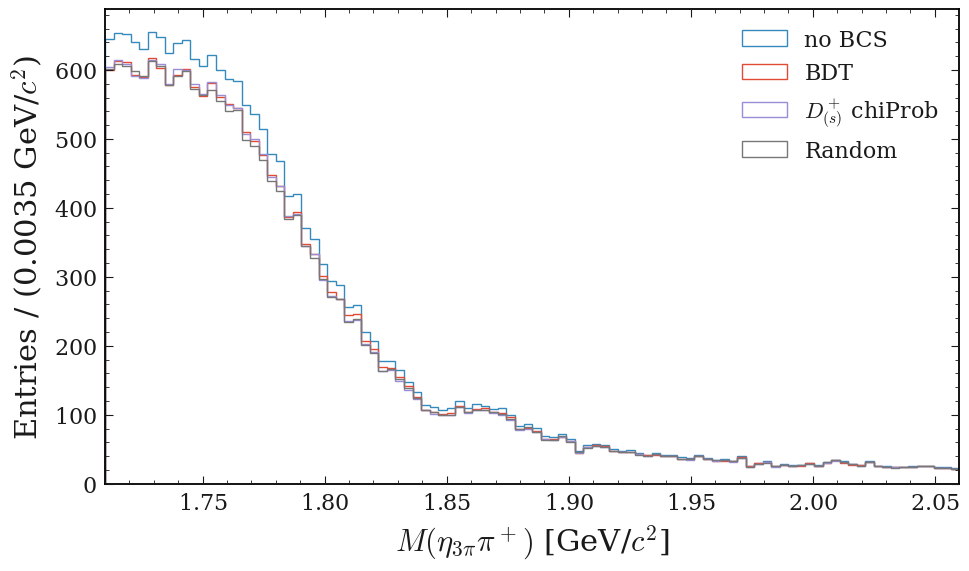

In [78]:
output = os.path.join(plot_dir, "MC15rd_etapip_pipipi_ref_BCS_comparison.png")


fig, ax = plt.subplots(figsize=(10, 6))
xbins = np.linspace(*bins, 101)
bin_centers = (xbins[1:] + xbins[:-1]) / 2
bin_width = xbins[1] - xbins[0]
plt.hist(combined_mc_data_no_BCS.Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_no_BCS.ds_weight,label='no BCS');
plt.hist(combined_mc_data_BDT_BCS.Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_BDT_BCS.ds_weight,label='BDT');
plt.hist(combined_mc_data_Dp_chiProb_BCS.Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_Dp_chiProb_BCS.ds_weight,label=r'$D^+_{(s)}$ chiProb');
plt.hist(combined_mc_data_random_BCS.Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_random_BCS.ds_weight,label=r'Random');
plt.legend()
ax.set_xlim(*bins)
ax.set_xlabel(xlabel)
ax.set_ylabel(f"Entries / ({bin_width:.4f} GeV/$c^2$)")
plt.tight_layout()
plt.savefig(output)

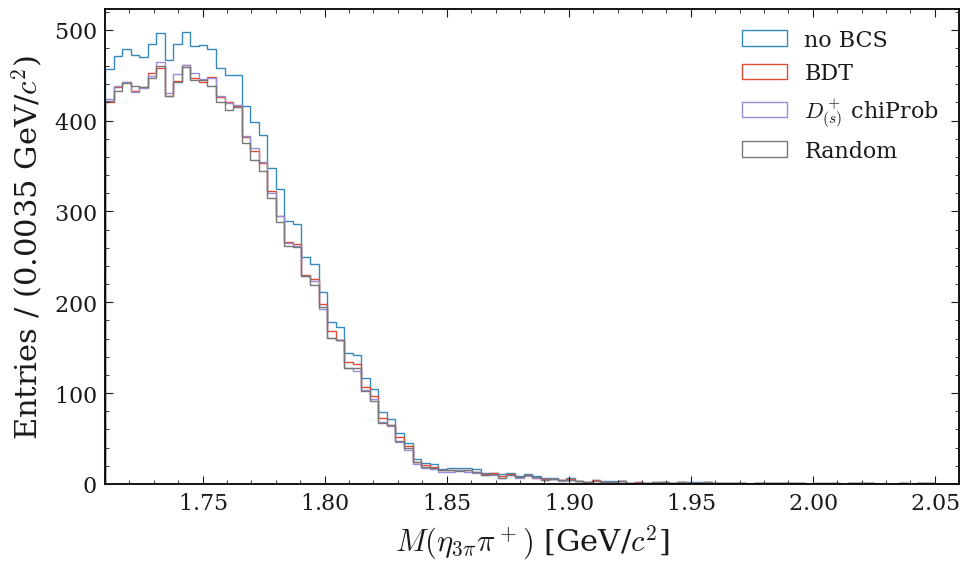

In [79]:
output = os.path.join(plot_dir, "MC15rd_etapip_pipipi_ref_BCS_comparison_onlyrhopeta.png")


fig, ax = plt.subplots(figsize=(10, 6))
xbins = np.linspace(*bins, 101)
bin_centers = (xbins[1:] + xbins[:-1]) / 2
bin_width = xbins[1] - xbins[0]
plt.hist(combined_mc_data_no_BCS.query("(nAllSigCascDcyBr_16 > 0)").Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_no_BCS.query("(nAllSigCascDcyBr_16 > 0)").ds_weight,label='no BCS');
plt.hist(combined_mc_data_BDT_BCS.query("(nAllSigCascDcyBr_16 > 0)").Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_BDT_BCS.query("(nAllSigCascDcyBr_16 > 0)").ds_weight,label='BDT');
plt.hist(combined_mc_data_Dp_chiProb_BCS.query("(nAllSigCascDcyBr_16 > 0)").Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_Dp_chiProb_BCS.query("(nAllSigCascDcyBr_16 > 0)").ds_weight,label=r'$D^+_{(s)}$ chiProb');
plt.hist(combined_mc_data_random_BCS.query("(nAllSigCascDcyBr_16 > 0)").Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_random_BCS.query("(nAllSigCascDcyBr_16 > 0)").ds_weight,label=r'Random');
plt.legend()
ax.set_xlim(*bins)
ax.set_xlabel(xlabel)
ax.set_ylabel(f"Entries / ({bin_width:.4f} GeV/$c^2$)")
plt.tight_layout()
plt.savefig(output)

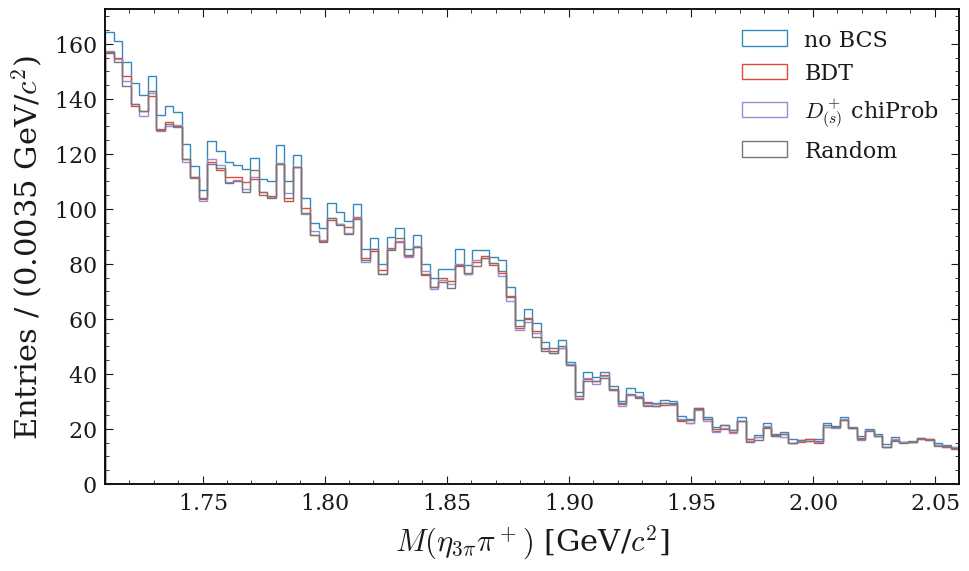

In [80]:
output = os.path.join(plot_dir, "MC15rd_etapip_pipipi_BCS_comparison_no_rhopeta.png")


fig, ax = plt.subplots(figsize=(10, 6))
xbins = np.linspace(*bins, 101)
bin_centers = (xbins[1:] + xbins[:-1]) / 2
bin_width = xbins[1] - xbins[0]
plt.hist(combined_mc_data_no_BCS.query("(nAllSigCascDcyBr_16 <= 0)").Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_no_BCS.query("(nAllSigCascDcyBr_16 <= 0)").ds_weight,label='no BCS');
plt.hist(combined_mc_data_BDT_BCS.query("(nAllSigCascDcyBr_16 <= 0)").Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_BDT_BCS.query("(nAllSigCascDcyBr_16 <= 0)").ds_weight,label='BDT');
plt.hist(combined_mc_data_Dp_chiProb_BCS.query("(nAllSigCascDcyBr_16 <= 0)").Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_Dp_chiProb_BCS.query("(nAllSigCascDcyBr_16 <= 0)").ds_weight,label=r'$D^+_{(s)}$ chiProb');
plt.hist(combined_mc_data_random_BCS.query("(nAllSigCascDcyBr_16 <= 0)").Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=combined_mc_data_random_BCS.query("(nAllSigCascDcyBr_16 <= 0)").ds_weight,label=r'Random');
plt.legend()
ax.set_xlim(*bins)
ax.set_xlabel(xlabel)
ax.set_ylabel(f"Entries / ({bin_width:.4f} GeV/$c^2$)")
plt.tight_layout()
plt.savefig(output)

In [69]:
# mc_data_BDT_BCS

In [11]:
test_df = mc_data_no_BCS['ccbar_bkg_comb'].query('nAllSigCascDcyBr_4>0 or nAllSigCascDcyBr_8 > 0')

In [20]:
mc_data_no_BCS['ccbar_bkg_comb'].query('Dp_M >1.83 and Dp_M<1.90')

,Dp_M,ds_weight,nAllSigCascDcyBr_14,Dp_chiProb,nAllSigCascDcyBr_4,nAllSigCascDcyBr_8,BDT,nAllSigCascDcyBr_16,Pip_mcPDG,etapip_Eta_isSignal,Pip_genMotherPDG,Pip_genMotherID,etapip_Eta_genMotherPDG,etapip_Eta_genMotherID,__experiment__,__run__,__event__,__production__
10,1.834788,0.25,0,0.014467,0,0,0.937198,0,-211.0,0.0,-421.0,6.0,0.0,0.0,10,3400,24808,28386
43,1.889567,0.25,0,0.061501,0,0,0.974338,0,13.0,1.0,-431.0,14.0,-431.0,14.0,10,3507,33633,28386
320,1.837195,0.25,0,0.004101,0,0,0.974796,0,-211.0,0.0,-213.0,34.0,-433.0,9.0,10,3743,38997,28386
334,1.833070,0.25,0,0.520444,0,0,0.965530,1,-211.0,1.0,-213.0,19.0,-431.0,8.0,10,3745,179042,28386
355,1.842726,0.25,1,0.594844,0,0,0.966900,0,-321.0,1.0,-431.0,9.0,-431.0,9.0,10,3745,22680,28386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
313027,1.830407,0.25,0,0.001011,0,0,0.951948,0,-211.0,NaN,-431.0,17.0,0.0,0.0,18,2559,622081,29599
313104,1.830740,0.25,0,0.077907,0,0,0.962346,1,211.0,1.0,213.0,8.0,431.0,5.0,18,2560,644157,29599
313177,1.877492,0.25,0,0.005569,0,0,0.948474,0,-211.0,0.0,-411.0,17.0,-413.0,7.0,18,2560,505025,29599
313203,1.844567,0.25,0,0.047990,0,0,0.986802,0,-211.0,0.0,-213.0,13.0,23.0,2.0,18,2560,544863,29599


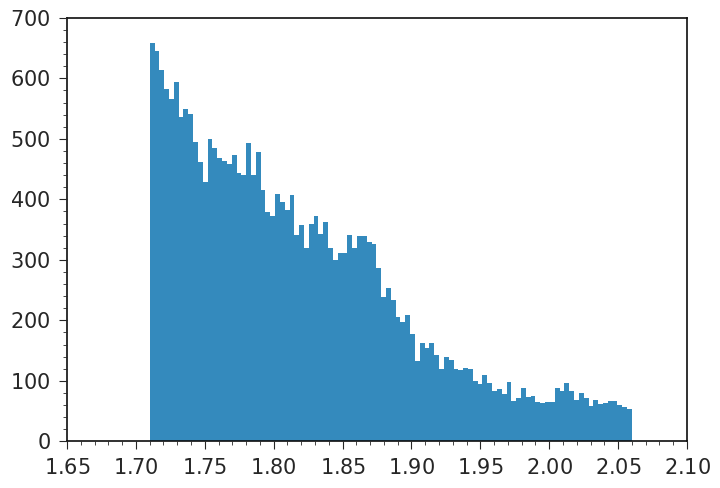

In [40]:
plt.hist(mc_data_no_BCS['ccbar_bkg_comb'].Dp_M,bins= np.linspace(*bins, 101));

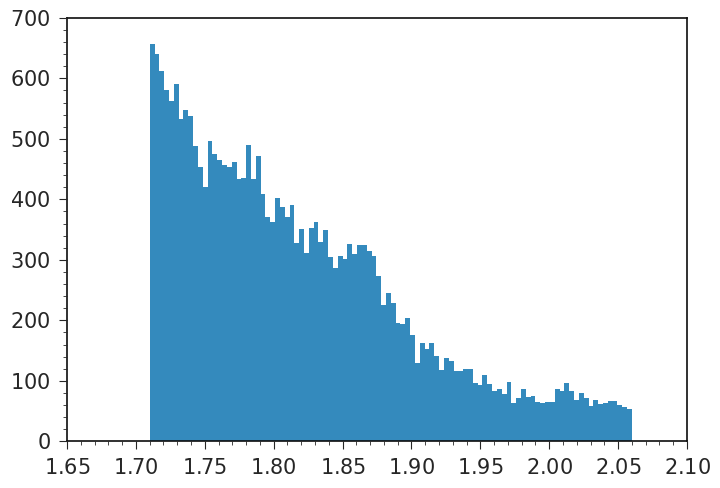

In [41]:
plt.hist(mc_data_no_BCS['ccbar_bkg_comb'].query('nAllSigCascDcyBr_14<=0').Dp_M,bins= np.linspace(*bins, 101));

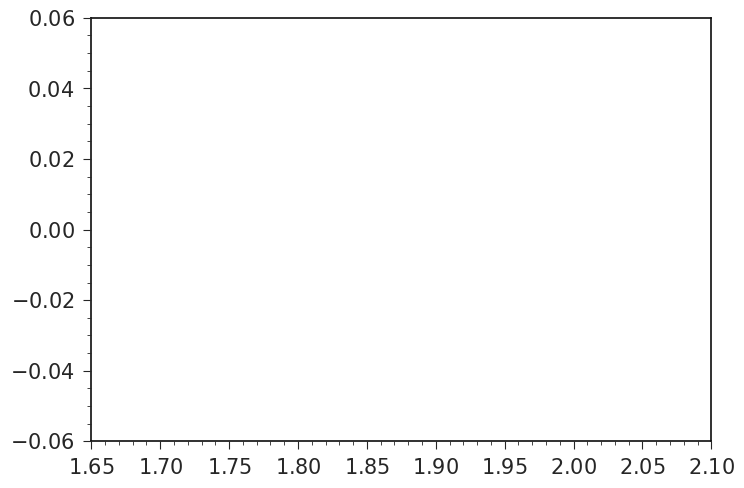

In [12]:
plt.hist(test_df.Dp_M,bins= np.linspace(*bins, 101));

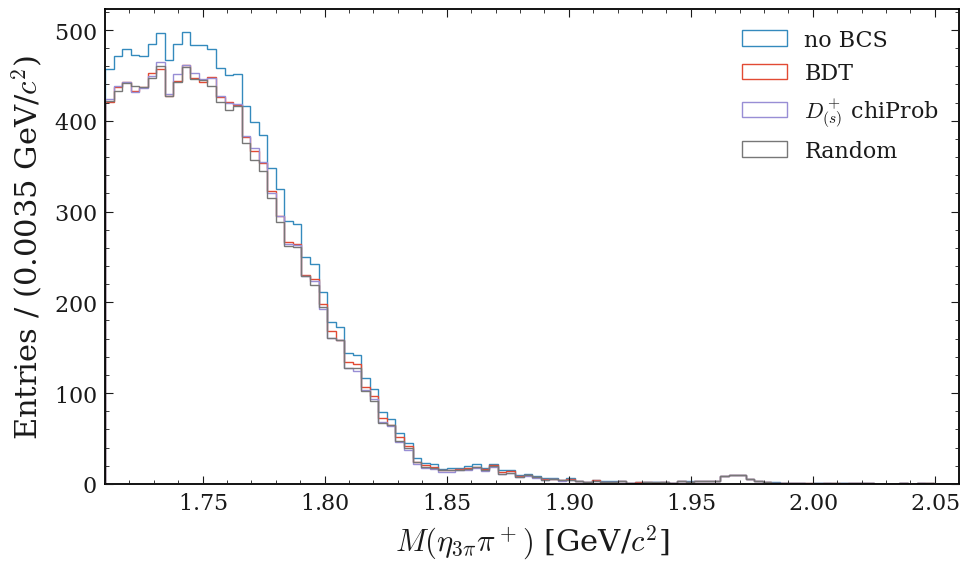

In [76]:
output = os.path.join(plot_dir, "MC15rd_etapip_pipipi_ref_BCS_comparison_onlyrhopeta.png")

fig, ax = plt.subplots(figsize=(10, 6))
xbins = np.linspace(*bins, 101)
bin_centers = (xbins[1:] + xbins[:-1]) / 2
bin_width = xbins[1] - xbins[0]
plt.hist(mc_data_no_BCS['ccbar_bkg_comb'].Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=mc_data_no_BCS['ccbar_bkg_comb'].ds_weight,label='no BCS');
plt.hist(mc_data_BDT_BCS['ccbar_bkg_comb'].Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=mc_data_BDT_BCS['ccbar_bkg_comb'].ds_weight,label='BDT');
plt.hist(mc_data_Dp_chiProb_BCS['ccbar_bkg_comb'].Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=mc_data_Dp_chiProb_BCS['ccbar_bkg_comb'].ds_weight,label=r'$D^+_{(s)}$ chiProb');
plt.hist(mc_data_random_BCS['ccbar_bkg_comb'].Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=mc_data_random_BCS['ccbar_bkg_comb'].ds_weight,label=r'Random');
plt.legend()
ax.set_xlim(*bins)
ax.set_xlabel(xlabel)
ax.set_ylabel(f"Entries / ({bin_width:.4f} GeV/$c^2$)")
plt.tight_layout()
# plt.savefig(output)

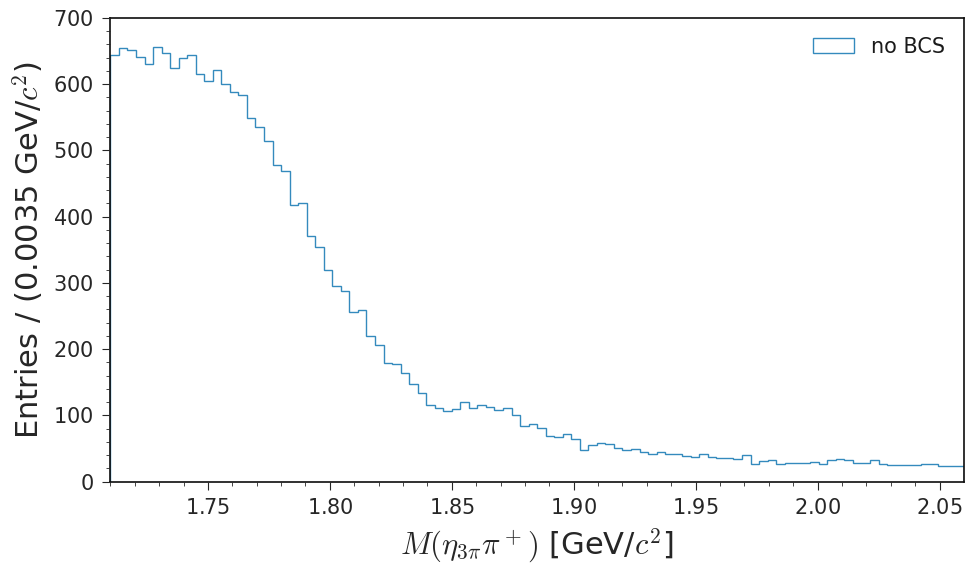

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
xbins = np.linspace(*bins, 101)
bin_width = xbins[1] - xbins[0]

# ==== dictionary 목록 ====
data_dicts = {
    "no BCS": mc_data_no_BCS,
    # "BDT no BCS": mc_data_BDT_BCS,
    # r"$D^+_{(s)}$ chiProb": mc_data_Dp_chiProb_BCS,
    # "Random": mc_data_random_BCS,
}

# ==== 각 dict을 단 1개의 히스토그램으로 ====
for label, data_dict in data_dicts.items():
    # 모든 key 중 'ccbar_bkg_comb' 제외하고 concat
    dfs = [
        df for key, df in data_dict.items()
        # if key != "ccbar_bkg_comb"
    ]

    if len(dfs) == 0:
        continue

    # 하나의 큰 df로 결합
    combined_df = pd.concat(dfs, ignore_index=True)

    # 히스토그램 그리기
    plt.hist(
        combined_df["Dp_M"],
        bins=xbins,
        histtype="step",
        weights=combined_df["ds_weight"],
        label=label
    )

plt.legend()
ax.set_xlim(*bins)
ax.set_xlabel(xlabel)
ax.set_ylabel(f"Entries / ({bin_width:.4f} GeV/$c^2$)")
plt.tight_layout()
# plt.savefig(output)

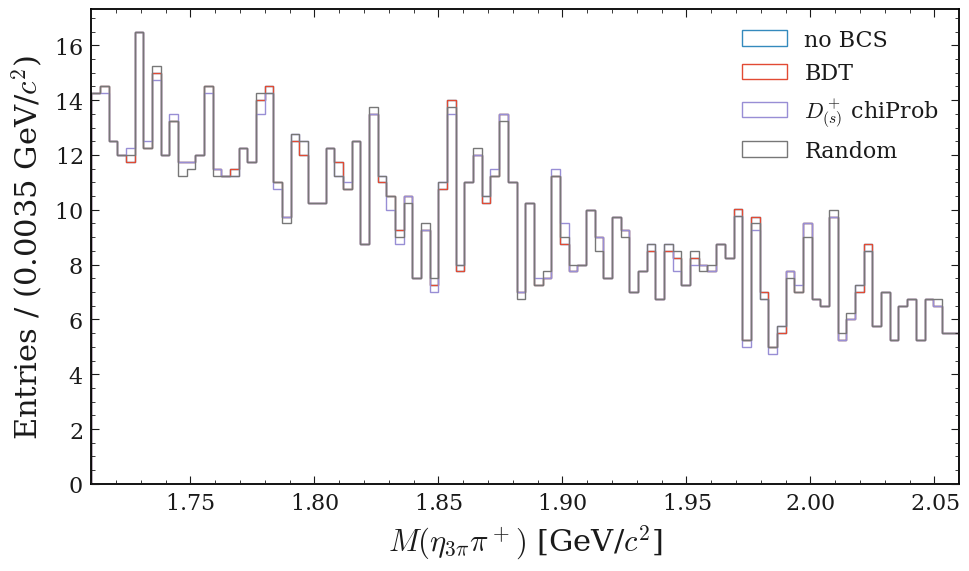

In [57]:
sample = 'uubar'

fig, ax = plt.subplots(figsize=(10, 6))
xbins = np.linspace(*bins, 101)
bin_centers = (xbins[1:] + xbins[:-1]) / 2
bin_width = xbins[1] - xbins[0]
plt.hist(mc_data_BDT_BCS[sample].Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=mc_data_BDT_BCS[sample].ds_weight,label='no BCS');
plt.hist(mc_data_BDT_BCS[sample].Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=mc_data_BDT_BCS[sample].ds_weight,label='BDT');
plt.hist(mc_data_Dp_chiProb_BCS[sample].Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=mc_data_Dp_chiProb_BCS[sample].ds_weight,label=r'$D^+_{(s)}$ chiProb');
plt.hist(mc_data_random_BCS[sample].Dp_M,bins=np.linspace(*bins, 101),histtype='step', weights=mc_data_random_BCS[sample].ds_weight,label=r'Random');
plt.legend()
ax.set_xlim(*bins)
ax.set_xlabel(xlabel)
ax.set_ylabel(f"Entries / ({bin_width:.4f} GeV/$c^2$)")
plt.tight_layout()